# 02 - XGBoost Model

Ce notebook entraine un modele XGBoost pour la prevision des ventes.
**Utilise exactement les memes patterns que `train.py` pour garantir la coherence.**

**Outputs:**
- `models/artifacts/xgb_model_YYYYMMDD.pkl`
- `models/artifacts/xgb_config_YYYYMMDD.json`
- `models/metrics/xgb_metrics_YYYYMMDD.json`
- `models/metrics/xgb_feature_importance_YYYYMMDD.csv`

In [19]:
import sys
import json
import datetime
import warnings
from pathlib import Path
from math import sqrt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')

# Setup project path - SAME AS train.py
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\richa\Prediction_de_vente\Prediction_de_vente


In [20]:
# ============================================================
# CONFIGURATION - SAME AS train.py
# ============================================================
HORIZON = 14
LAGS = [14, 21, 28, 35, 42]  # All >= HORIZON to avoid data leakage
WINDOWS = [14, 21, 28]       # All >= HORIZON
DATE_COL = 'date'
TARGET_COL = 'value'
TODAY = datetime.datetime.now().strftime("%Y%m%d")

# Paths
ARTIFACTS_PATH = PROJECT_ROOT / "models" / "artifacts"
METRICS_PATH = PROJECT_ROOT / "models" / "metrics"
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# Import project config
try:
    from src.config import TRAIN_CSV, GROUP_COLS, FEATURE_EXCLUDE, CATEGORICAL_FEATURES
except ImportError:
    TRAIN_CSV = PROJECT_ROOT / "data" / "interim" / "train.csv"
    GROUP_COLS = ['store_id', 'product_id']
    FEATURE_EXCLUDE = {'date', 'value', 'store_id', 'product_id', 'id'}
    CATEGORICAL_FEATURES = ['store_id', 'product_id']

try:
    from src.data.features import build_feature_pipeline
    from src.data.clean import clean_dataframe
    PIPELINE_AVAILABLE = True
except ImportError:
    PIPELINE_AVAILABLE = False
    print("Warning: src.data modules not available")

print(f"HORIZON={HORIZON}, LAGS={LAGS}, WINDOWS={WINDOWS}")

HORIZON=14, LAGS=[14, 21, 28, 35, 42], WINDOWS=[14, 21, 28]


In [21]:
# Find data file - SAME LOGIC AS train.py
def find_data_file():
    candidates = [
        TRAIN_CSV,
        PROJECT_ROOT / "data" / "processed" / "uploaded_generated_training_10950_features.csv",
        PROJECT_ROOT / "data" / "processed" / "train_features.csv",
    ]
    for folder in ["interim", "processed", "raw"]:
        folder_path = PROJECT_ROOT / "data" / folder
        if folder_path.exists():
            for f in folder_path.glob("*.csv"):
                candidates.append(f)
    
    for p in candidates:
        if p and p.exists():
            return p
    raise FileNotFoundError("No data file found")

DATA_PATH = find_data_file()
print(f"Data: {DATA_PATH}")

Data: C:\Users\richa\Prediction_de_vente\Prediction_de_vente\data\interim\train.csv


## 1. Load and Prepare Data (SAME AS train.py)

In [22]:
import re

# Load data
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
print(f"Raw shape: {df.shape}")

# Apply cleaning - SAME AS train.py load_and_prepare()
if PIPELINE_AVAILABLE:
    try:
        df = clean_dataframe(df, date_col=DATE_COL, value_col=TARGET_COL, 
                             fill_strategy='ffill', outlier_threshold=None)
        print("clean_dataframe() applied")
    except Exception as e:
        print(f"clean_dataframe failed: {e}")

# Remove pre-computed short-horizon columns - SAME AS train.py
short_col_re = re.compile(
    r"^(?:lag|roll_mean|roll_std|roll_min|roll_max|roll_range|roll_cv|ewma|lag_diff|lag_ratio)_(\d+)"
)
cols_to_drop = [c for c in df.columns if (m := short_col_re.match(c)) and int(m.group(1)) < HORIZON]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} short-horizon columns")

# Remap columns
if 'store_id' not in df.columns and 'id' in df.columns:
    df = df.rename(columns={'id': 'store_id'})

# Handle on_promo
if 'on_promo' in df.columns:
    df['on_promo'] = df['on_promo'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0}
    ).fillna(0).astype(int)

# Detect group columns
available_groups = [c for c in GROUP_COLS if c in df.columns]
print(f"Group columns: {available_groups}")

# Sort by group + date
sort_cols = available_groups + [DATE_COL]
df = df.sort_values(sort_cols).reset_index(drop=True)

Raw shape: (8205, 7)
clean_dataframe() applied
Group columns: ['store_id', 'product_id']


In [23]:
# Build feature pipeline - SAME AS train.py
if PIPELINE_AVAILABLE:
    cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]
    
    df, encoders = build_feature_pipeline(
        df,
        lags=LAGS,
        windows=WINDOWS,
        group_cols=available_groups if available_groups else None,
        categorical_cols=cat_cols if cat_cols else None,
        is_train=True,
        horizon=HORIZON,
    )
    print(f"Features built: {df.shape}")
else:
    encoders = {}
    print("Feature pipeline not available - using raw data")

# Drop NaN rows
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df)} NaN rows, final: {len(df)}")

Features built: (8205, 58)
Dropped 630 NaN rows, final: 7575


In [24]:
print(f"\nDataset shape: {df.shape}")
print(f"Target stats: mean={df[TARGET_COL].mean():.2f}, std={df[TARGET_COL].std():.2f}")
print(f"Target range: [{df[TARGET_COL].min():.2f}, {df[TARGET_COL].max():.2f}]")


Dataset shape: (7575, 58)
Target stats: mean=1153.03, std=9878.42
Target range: [0.00, 284905.00]


## 2. Train/Test Split (SAME AS train.py)

In [25]:
def split_time_series(df, horizon, date_col, target_col, exclude_cols):
    """Split into train/test - EXACT COPY FROM train.py"""
    exclude_cols = set(exclude_cols) | {target_col, date_col}
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    unique_dates = sorted(df[date_col].unique())
    if horizon >= len(unique_dates):
        horizon = max(1, len(unique_dates) // 5)
    
    cutoff_date = unique_dates[-horizon]
    train_mask = df[date_col] < cutoff_date
    test_mask = df[date_col] >= cutoff_date
    
    X_train = df.loc[train_mask, feature_cols].copy()
    y_train = df.loc[train_mask, target_col].copy()
    X_test = df.loc[test_mask, feature_cols].copy()
    y_test = df.loc[test_mask, target_col].copy()
    dates_test = df.loc[test_mask, date_col].copy()
    
    return X_train, y_train, X_test, y_test, dates_test

X_train, y_train, X_test, y_test, dates_test = split_time_series(
    df, HORIZON, DATE_COL, TARGET_COL, FEATURE_EXCLUDE
)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Features: {X_train.shape[1]}")

Train: 7365 samples
Test: 210 samples
Features: 55


In [26]:
# Create validation set for early stopping - SAME AS train.py
val_size = max(int(len(X_train) * 0.15), HORIZON)
X_tr = X_train.iloc[:-val_size]
y_tr = y_train.iloc[:-val_size]
X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]

print(f"Train/Val split: {len(X_tr)} / {len(X_val)}")

Train/Val split: 6261 / 1104


In [27]:
# CRITICAL: Coerce object columns - EXACT COPY FROM train.py
def _coerce_object_columns(df_in):
    """Ensure all columns are numeric for tree models."""
    df_out = df_in.copy()
    for c in df_out.columns:
        if pd.api.types.is_object_dtype(df_out[c].dtype) or isinstance(df_out[c].dtype, pd.CategoricalDtype):
            try:
                df_out[c] = pd.Categorical(df_out[c]).codes
            except Exception:
                df_out[c] = pd.to_numeric(df_out[c], errors='coerce').fillna(0).astype(float)
    return df_out

X_tr = _coerce_object_columns(X_tr)
X_val = _coerce_object_columns(X_val)
X_test = _coerce_object_columns(X_test)
X_train_full = _coerce_object_columns(X_train)

print("Columns coerced to numeric")
print(f"Dtypes: {X_tr.dtypes.value_counts().to_dict()}")

Columns coerced to numeric
Dtypes: {dtype('float64'): 39, dtype('int32'): 7, dtype('int64'): 5, dtype('int8'): 4}


## 3. XGBoost Training

In [28]:
from xgboost import XGBRegressor

# Default params - SAME AS train.py _default_xgb_params()
xgb_params = {
    'n_estimators': 1000,
    'max_depth': 6,
    'learning_rate': 0.05,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'early_stopping_rounds': 50,
    'verbosity': 0,
}

print("XGBoost params:")
for k, v in xgb_params.items():
    print(f"  {k}: {v}")

XGBoost params:
  n_estimators: 1000
  max_depth: 6
  learning_rate: 0.05
  min_child_weight: 5
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 1.0
  random_state: 42
  early_stopping_rounds: 50
  verbosity: 0


In [29]:
# Train XGBoost - SAME AS train.py train_xgb()
print("\nTraining XGBoost...")
model = XGBRegressor(**xgb_params)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print(f"Best iteration: {model.best_iteration}")


Training XGBoost...
Best iteration: 455


## 4. Evaluation (SAME AS train.py)

In [30]:
def evaluate_model(model, X_train, y_train, X_test, y_test, X_all, y_all, n_cv_splits=5):
    """Evaluate model - SAME LOGIC AS train.py evaluate_model()"""
    
    # Train predictions
    y_pred_train = model.predict(X_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    bias_train = float(np.mean(y_pred_train - y_train))
    
    # Test predictions
    y_pred_test = model.predict(X_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    bias_test = float(np.mean(y_pred_test - y_test))
    
    # Bias-corrected
    y_pred_corrected = y_pred_test - bias_test
    mae_corrected = mean_absolute_error(y_test, y_pred_corrected)
    rmse_corrected = sqrt(mean_squared_error(y_test, y_pred_corrected))
    r2_corrected = r2_score(y_test, y_pred_corrected)
    
    # Safe MAPE
    y_test_arr = np.array(y_test)
    mask = np.abs(y_test_arr) > 1.0
    mape = float(np.mean(np.abs((y_test_arr[mask] - y_pred_test[mask]) / y_test_arr[mask])) * 100) if mask.sum() > 0 else None
    
    # sMAPE
    denom = (np.abs(y_test_arr) + np.abs(y_pred_test)) / 2
    denom_safe = np.where(denom > 0, denom, 1.0)
    smape = float(np.mean(np.abs(y_test_arr - y_pred_test) / denom_safe) * 100)
    
    # Cross-validation
    tscv = TimeSeriesSplit(n_splits=min(n_cv_splits, max(2, len(X_all) // 100)))
    cv_scores = {'mae': [], 'r2': []}
    
    for train_idx, val_idx in tscv.split(X_all):
        X_cv_tr, X_cv_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_cv_tr, y_cv_val = y_all.iloc[train_idx], y_all.iloc[val_idx]
        
        model_cv = XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            random_state=42, early_stopping_rounds=30, verbosity=0,
        )
        model_cv.fit(X_cv_tr, y_cv_tr, eval_set=[(X_cv_val, y_cv_val)], verbose=False)
        
        y_cv_pred = model_cv.predict(X_cv_val)
        cv_scores['mae'].append(mean_absolute_error(y_cv_val, y_cv_pred))
        cv_scores['r2'].append(r2_score(y_cv_val, y_cv_pred))
    
    overfit_ratio = rmse_test / rmse_train if rmse_train > 0 else float('inf')
    
    return {
        'MAE_train': mae_train, 'RMSE_train': rmse_train, 'R2_train': r2_train, 'Bias_train': bias_train,
        'MAE_test': mae_test, 'RMSE_test': rmse_test, 'R2_test': r2_test, 'Bias_test': bias_test,
        'MAE_test_corrected': mae_corrected, 'RMSE_test_corrected': rmse_corrected, 'R2_test_corrected': r2_corrected,
        'MAPE_test': mape, 'sMAPE_test': smape,
        'overfit_ratio': overfit_ratio,
        'CV_mae_mean': np.mean(cv_scores['mae']), 'CV_mae_std': np.std(cv_scores['mae']),
        'CV_r2_mean': np.mean(cv_scores['r2']), 'CV_r2_std': np.std(cv_scores['r2']),
        'y_pred_test': y_pred_test,
    }

In [31]:
# Evaluate
metrics = evaluate_model(model, X_train_full, y_train, X_test, y_test, X_train_full, y_train)

print("\n" + "="*60)
print("[XGBoost] RESULTS")
print("="*60)
print(f"  Train  -> MAE={metrics['MAE_train']:.4f}  RMSE={metrics['RMSE_train']:.4f}  R2={metrics['R2_train']:.4f}")
print(f"  Test   -> MAE={metrics['MAE_test']:.4f}  RMSE={metrics['RMSE_test']:.4f}  R2={metrics['R2_test']:.4f}")
print(f"  Test*  -> MAE={metrics['MAE_test_corrected']:.4f}  RMSE={metrics['RMSE_test_corrected']:.4f}  R2={metrics['R2_test_corrected']:.4f}  (* bias-corrected)")
print(f"  Bias   -> train={metrics['Bias_train']:.4f}  test={metrics['Bias_test']:.4f}")
print(f"  MAPE   -> {metrics['MAPE_test']:.2f}%" if metrics['MAPE_test'] else "  MAPE   -> N/A")
print(f"  sMAPE  -> {metrics['sMAPE_test']:.2f}%")
print(f"  Overfit ratio (RMSE_test/RMSE_train): {metrics['overfit_ratio']:.2f}")
print(f"  CV     -> MAE={metrics['CV_mae_mean']:.4f} (+/- {metrics['CV_mae_std']:.4f})")
print(f"  CV     -> R2={metrics['CV_r2_mean']:.4f} (+/- {metrics['CV_r2_std']:.4f})")
print("="*60)


[XGBoost] RESULTS
  Train  -> MAE=57.1416  RMSE=481.2948  R2=0.9977
  Test   -> MAE=62.9792  RMSE=112.1717  R2=0.9529
  Test*  -> MAE=61.9717  RMSE=109.1961  R2=0.9553  (* bias-corrected)
  Bias   -> train=-0.4676  test=25.6652
  MAPE   -> 11.22%
  sMAPE  -> 61.04%
  Overfit ratio (RMSE_test/RMSE_train): 0.23
  CV     -> MAE=113.9446 (+/- 110.0203)
  CV     -> R2=0.6777 (+/- 0.3888)


## 5. Feature Importance

In [32]:
# Feature importance
fi = pd.DataFrame({
    'feature': X_train_full.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 features:")
print(fi.head(20).to_string())

Top 20 features:
            feature  importance
0       roll_min_21    0.439130
1      day_of_month    0.166205
2       roll_min_28    0.147224
3       roll_min_14    0.144096
4               day    0.022718
5   day_of_year_sin    0.012917
6         dayofyear    0.011196
7      week_of_year    0.010335
8           dow_cos    0.009374
9           dow_sin    0.006367
10            month    0.004253
11        dayofweek    0.004043
12           lag_14    0.003753
13  day_of_year_cos    0.003020
14       roll_cv_14    0.002571
15    roll_range_14    0.001955
16      roll_max_14    0.001674
17  store_dayofweek    0.001291
18      roll_std_14    0.001109
19     roll_mean_14    0.001032


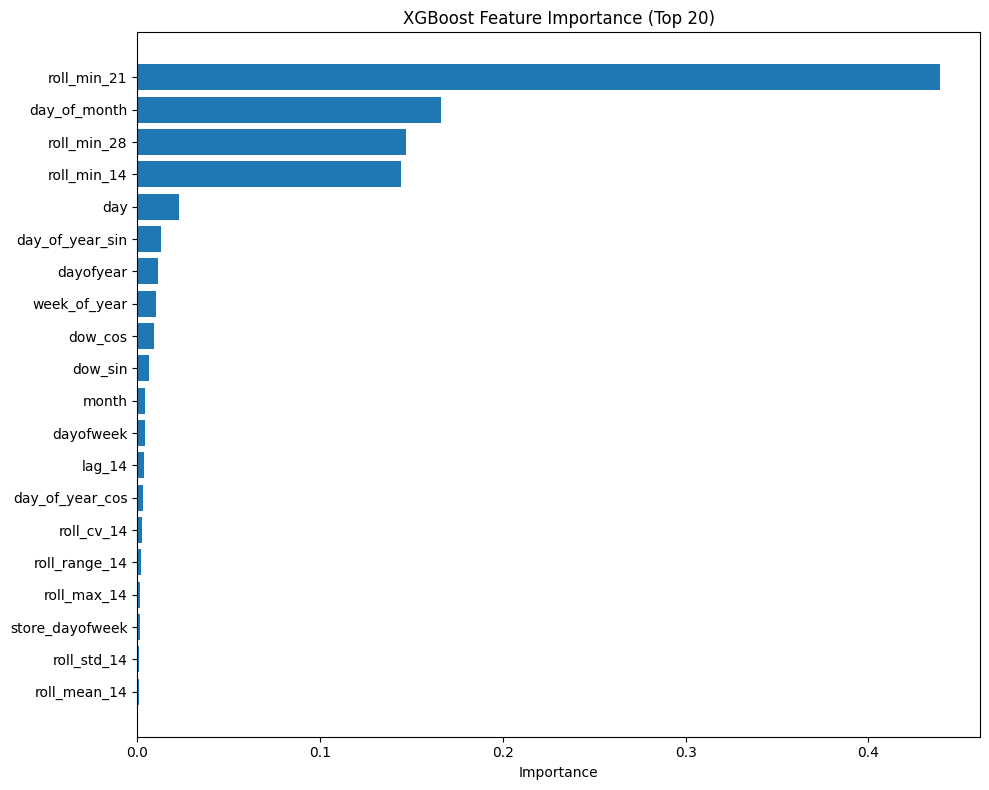

In [33]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(fi))
ax.barh(fi['feature'].head(top_n)[::-1], fi['importance'].head(top_n)[::-1])
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance (Top 20)')
plt.tight_layout()
plt.savefig(METRICS_PATH / f"xgb_feature_importance_{TODAY}.png", dpi=150)
plt.show()

## 6. Visualizations

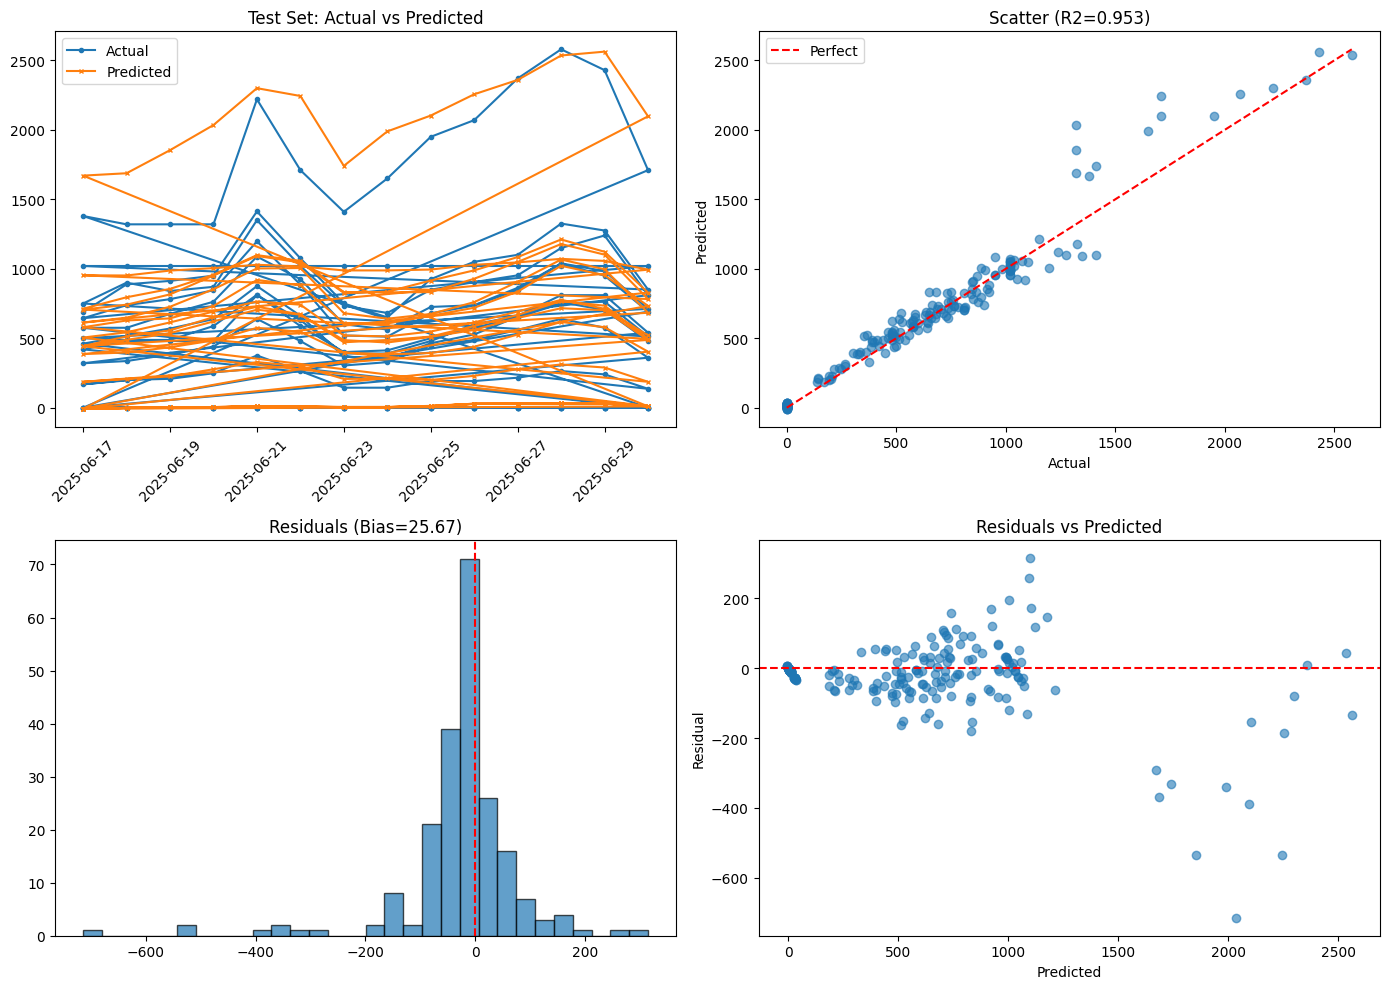

In [34]:
y_pred = metrics['y_pred_test']
y_true = y_test.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time series
ax1 = axes[0, 0]
ax1.plot(dates_test.values, y_true, label='Actual', marker='o', markersize=3)
ax1.plot(dates_test.values, y_pred, label='Predicted', marker='x', markersize=3)
ax1.set_title('Test Set: Actual vs Predicted')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# 2. Scatter
ax2 = axes[0, 1]
ax2.scatter(y_true, y_pred, alpha=0.6)
max_val = max(y_true.max(), y_pred.max())
ax2.plot([0, max_val], [0, max_val], 'r--', label='Perfect')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Scatter (R2={metrics["R2_test"]:.3f})')
ax2.legend()

# 3. Residuals
ax3 = axes[1, 0]
residuals = y_true - y_pred
ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='red', linestyle='--')
ax3.set_title(f'Residuals (Bias={metrics["Bias_test"]:.2f})')

# 4. Residuals vs Predicted
ax4 = axes[1, 1]
ax4.scatter(y_pred, residuals, alpha=0.6)
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Residual')
ax4.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig(METRICS_PATH / f"xgb_plots_{TODAY}.png", dpi=150)
plt.show()

## 7. Save Artifacts & Metrics

In [35]:
# Compile all metrics
all_metrics = {
    'model_type': 'XGBoost',
    'timestamp': datetime.datetime.now().isoformat(),
    'horizon': HORIZON,
    'lags': LAGS,
    'windows': WINDOWS,
    'num_train_samples': len(X_train_full),
    'num_test_samples': len(X_test),
    'num_features': X_train_full.shape[1],
    'feature_names': list(X_train_full.columns),
    'best_iteration': model.best_iteration,
    
    # Metrics
    'MAE_train': float(metrics['MAE_train']),
    'RMSE_train': float(metrics['RMSE_train']),
    'R2_train': float(metrics['R2_train']),
    'Bias_train': float(metrics['Bias_train']),
    'MAE_test': float(metrics['MAE_test']),
    'RMSE_test': float(metrics['RMSE_test']),
    'R2_test': float(metrics['R2_test']),
    'Bias_test': float(metrics['Bias_test']),
    'MAE_test_corrected': float(metrics['MAE_test_corrected']),
    'RMSE_test_corrected': float(metrics['RMSE_test_corrected']),
    'R2_test_corrected': float(metrics['R2_test_corrected']),
    'MAPE_test': metrics['MAPE_test'],
    'sMAPE_test': float(metrics['sMAPE_test']),
    'overfit_ratio': float(metrics['overfit_ratio']),
    'CV_mae_mean': float(metrics['CV_mae_mean']),
    'CV_mae_std': float(metrics['CV_mae_std']),
    'CV_r2_mean': float(metrics['CV_r2_mean']),
    'CV_r2_std': float(metrics['CV_r2_std']),
}

# Save metrics
metrics_file = METRICS_PATH / f"xgb_metrics_{TODAY}.json"
with open(metrics_file, 'w') as f:
    json.dump(all_metrics, f, indent=2, default=str)
print(f"Metrics saved: {metrics_file}")

# Save model
model_file = ARTIFACTS_PATH / f"xgb_model_{TODAY}.pkl"
joblib.dump(model, model_file)
print(f"Model saved: {model_file}")

# Save config
config = {
    'horizon': HORIZON,
    'lags': LAGS,
    'windows': WINDOWS,
    'params': xgb_params,
    'feature_names': list(X_train_full.columns),
    'bias_correction': -metrics['Bias_test'],
    'data_path': str(DATA_PATH),
}
config_file = ARTIFACTS_PATH / f"xgb_config_{TODAY}.json"
with open(config_file, 'w') as f:
    json.dump(config, f, indent=2)
print(f"Config saved: {config_file}")

# Save feature importance
fi_file = METRICS_PATH / f"xgb_feature_importance_{TODAY}.csv"
fi.to_csv(fi_file, index=False)
print(f"Feature importance saved: {fi_file}")

Metrics saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\xgb_metrics_20260309.json
Model saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\xgb_model_20260309.pkl
Config saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\xgb_config_20260309.json
Feature importance saved: c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\xgb_feature_importance_20260309.csv


## 8. Final Summary

In [36]:
# Verdict
r2 = metrics['R2_test']
if r2 >= 0.8:
    verdict = "Excellent model -- strong predictive power."
elif r2 >= 0.6:
    verdict = "Good model -- reasonable predictions."
elif r2 >= 0.4:
    verdict = "Fair model -- some predictive power."
else:
    verdict = "Weak model -- consider feature engineering or data quality."

print("\n" + "="*60)
print("XGBOOST MODEL - FINAL SUMMARY")
print("="*60)
print(f"  Model        : XGBoost")
print(f"  Horizon      : {HORIZON} days")
print(f"  Features     : {X_train_full.shape[1]}")
print(f"  Train samples: {len(X_train_full)}")
print(f"  Test samples : {len(X_test)}")
print()
print("  Test Metrics:")
print(f"    MAE   : {metrics['MAE_test']:.4f}")
print(f"    RMSE  : {metrics['RMSE_test']:.4f}")
print(f"    R2    : {metrics['R2_test']:.4f}")
print(f"    MAPE  : {metrics['MAPE_test']:.2f}%" if metrics['MAPE_test'] else "    MAPE  : N/A")
print(f"    sMAPE : {metrics['sMAPE_test']:.2f}%")
print()
print(f"  VERDICT: {verdict}")
print()
print("  Artifacts:")
print(f"    {model_file}")
print(f"    {config_file}")
print(f"    {metrics_file}")
print(f"    {fi_file}")
print("="*60)


XGBOOST MODEL - FINAL SUMMARY
  Model        : XGBoost
  Horizon      : 14 days
  Features     : 55
  Train samples: 7365
  Test samples : 210

  Test Metrics:
    MAE   : 62.9792
    RMSE  : 112.1717
    R2    : 0.9529
    MAPE  : 11.22%
    sMAPE : 61.04%

  VERDICT: Excellent model -- strong predictive power.

  Artifacts:
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\xgb_model_20260309.pkl
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\xgb_config_20260309.json
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\xgb_metrics_20260309.json
    c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\xgb_feature_importance_20260309.csv
